<a href="https://colab.research.google.com/github/Dounia-Awni/Chicago-Crime-Data-Analysis-2001-2022-/blob/main/Chicago_Crime_Data_Analysis_(2001%E2%80%932022).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Data Analysis (2001–2022)

* This notebook analyzes 22 years of crime reports from the City of Chicago (2001–2022, ~7.7 million records) to answer stakeholder questions for a reporter covering crime trends.

##Load data and preprocessing

In [8]:
#Import required libraries
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from datetime import timedelta
from scipy.stats import linregress
from pandas.tseries.holiday import USFederalHolidayCalendar

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_rows', 40)
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Install holiday library
%pip install holidays

In [3]:
#Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Unzip the Chicago Crime dataset and extracts its contents to a specified directory.
#then list the files found in the output directory to confirm successful extraction.

import zipfile, os, glob

# ── Step 1: Unzip ────────────────────────────
ZIP_FILE   = "/content/drive/MyDrive/AXSOSACADEMY/04-AdvancedML/Week21/Data/Chicago_Crime_2001-2022.zip"   # path to the downloaded zip
OUTPUT_DIR = "/content/Data/Data/"               # folder where CSVs will be extracted

with zipfile.ZipFile(ZIP_FILE, 'r') as zf:
    zf.extractall(OUTPUT_DIR)

print(f"Extracted to: {OUTPUT_DIR}")
print("Files found:", sorted(os.listdir(OUTPUT_DIR)))

Extracted to: /content/Data/Data/
Files found: ['Data']


In [5]:
#loading all individual CSV files into a list of DataFrames and then concatenates them into a single master DataFrame.

crime_files = sorted(glob.glob(OUTPUT_DIR + "Data/Chicago-Crime_*.csv"))
print(f"Found {len(crime_files)} CSV files")

dfs = []
for f in crime_files:
    temp_df = pd.read_csv(f)
    dfs.append(temp_df)
    print(f"  Loaded: {os.path.basename(f)}  →  {len(temp_df):,} rows")

# ── Step 3: Concatenate into one master DataFrame ───────────────────
df = pd.concat(dfs, ignore_index=True)

#Show df info and head
df.info()
df.head()

Found 22 CSV files
  Loaded: Chicago-Crime_2001.csv  →  485,886 rows
  Loaded: Chicago-Crime_2002.csv  →  486,807 rows
  Loaded: Chicago-Crime_2003.csv  →  475,985 rows
  Loaded: Chicago-Crime_2004.csv  →  469,422 rows
  Loaded: Chicago-Crime_2005.csv  →  453,773 rows
  Loaded: Chicago-Crime_2006.csv  →  448,179 rows
  Loaded: Chicago-Crime_2007.csv  →  437,087 rows
  Loaded: Chicago-Crime_2008.csv  →  427,183 rows
  Loaded: Chicago-Crime_2009.csv  →  392,827 rows
  Loaded: Chicago-Crime_2010.csv  →  370,513 rows
  Loaded: Chicago-Crime_2011.csv  →  351,993 rows
  Loaded: Chicago-Crime_2012.csv  →  336,319 rows
  Loaded: Chicago-Crime_2013.csv  →  307,536 rows
  Loaded: Chicago-Crime_2014.csv  →  275,789 rows
  Loaded: Chicago-Crime_2015.csv  →  264,787 rows
  Loaded: Chicago-Crime_2016.csv  →  269,823 rows
  Loaded: Chicago-Crime_2017.csv  →  269,100 rows
  Loaded: Chicago-Crime_2018.csv  →  268,899 rows
  Loaded: Chicago-Crime_2019.csv  →  261,325 rows
  Loaded: Chicago-Crime_2020.cs

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


In [6]:
#Convert the 'Date' column to datetime objects and sets it as the DataFrame's index.
df['Date'] = pd.to_datetime(df['Date'], format="%m/%d/%Y %I:%M:%S %p")
df = df.sort_values('Date').set_index('Date')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7713109 entries, 2001-01-01 00:00:00 to 2022-12-31 23:55:00
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Primary Type          object 
 2   Description           object 
 3   Location Description  object 
 4   Arrest                bool   
 5   Domestic              bool   
 6   Beat                  int64  
 7   District              float64
 8   Ward                  float64
 9   Latitude              float64
 10  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 603.2+ MB


,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
Date,,,,,,,,,,,
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923
2001-01-01,1927872,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137
2001-01-01,4768442,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707
2001-01-01,2280620,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782
2001-01-01,9755214,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN


In [9]:
#Check for null (missing) values in each column of the DataFrame.
null = df.isna().sum()
null

,0
ID,0
Primary Type,0
Description,0
Location Description,10928
Arrest,0
Domestic,0
Beat,0
District,47
Ward,614846
Latitude,88685


### Impute the null values with appropriate method for each feature

In [10]:
#filling any missing values in the 'Location Description' column with the string 'UNKNOWN'.
df['Location Description'] = df['Location Description'].fillna('UNKNOWN')
print(f"Null values in 'Location Description' after imputation: {df['Location Description'].isnull().sum()}")

Null values in 'Location Description' after imputation: 0


In [11]:
#filling missing values in the 'District' column with the mode (most frequent value).
district_mode = df['District'].mode()[0]
df['District'] = df['District'].fillna(district_mode)
print(f"Null values in 'District' after imputation: {df['District'].isnull().sum()}")

Null values in 'District' after imputation: 0


In [12]:
#filling missing values in the 'Ward' column with the mode (most frequent value).
ward_mode = df['Ward'].mode()[0]
df['Ward'] = df['Ward'].fillna(ward_mode)
print(f"Null values in 'Ward' after imputation: {df['Ward'].isnull().sum()}")

Null values in 'Ward' after imputation: 0


In [13]:
#imputing missing 'Latitude' and 'Longitude' values using linear interpolation.

df['Latitude'] = df['Latitude'].interpolate(method='linear')
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].median())

df['Longitude'] = df['Longitude'].interpolate(method='linear')
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].median())

print(f"Null values in 'Latitude' after imputation: {df['Latitude'].isnull().sum()}")
print(f"Null values in 'Longitude' after imputation: {df['Longitude'].isnull().sum()}")

Null values in 'Latitude' after imputation: 0
Null values in 'Longitude' after imputation: 0


In [14]:
#confirming that all null values across the entire DataFrame have been successfully imputed.
null = df.isna().sum().sum()
null

np.int64(0)

In [15]:
#check for duplicate rows in the DataFrame.
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [16]:
#resampling the DataFrame to count the number of crimes per day.
df_daily_counts = df.resample('D').size().rename('daily_crime_counts')

print("Daily crime counts (first 5 rows):")
display(df_daily_counts.head())
print("\nDaily crime counts (last 5 rows):")
display(df_daily_counts.tail())

Daily crime counts (first 5 rows):


,daily_crime_counts
Date,
2001-01-01,1825
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267



Daily crime counts (last 5 rows):


,daily_crime_counts
Date,
2022-12-27,583
2022-12-28,618
2022-12-29,648
2022-12-30,674
2022-12-31,726


##Topic 1: Comparing Police Districts
**Q: Which district had the most crimes in 2022? Which had the least?**

In [17]:
#filtering the DataFrame to include only crime data from the year 2022.
df_2022 = df.loc['2022']

# Group by 'District' and count crimes, then sort by crime count in descending order
crimes_by_district_2022 = df_2022['District'].value_counts().sort_values(ascending=False)
crimes_by_district_2022

,count
District,
8.0,14805
6.0,14694
12.0,14341
4.0,13931
11.0,13457
1.0,13044
18.0,12429
19.0,12243
25.0,11951


In [18]:
# identifing the police districts with the most and least crimes in 2022.
# Get district with most crimes using idxmax()
most_crimes_district = crimes_by_district_2022.idxmax()
most_crimes_count = crimes_by_district_2022.max()

# Get district with least crimes using idxmin()
least_crimes_district = crimes_by_district_2022.idxmin()
least_crimes_count = crimes_by_district_2022.min()

print(f"In 2022, the district with the most crimes was District {int(most_crimes_district)} with {most_crimes_count:,} crimes.")
print(f"In 2022, the district with the least crimes was District {int(least_crimes_district)} with {least_crimes_count:,} crimes.")

In 2022, the district with the most crimes was District 8 with 14,805 crimes.
In 2022, the district with the least crimes was District 31 with 15 crimes.


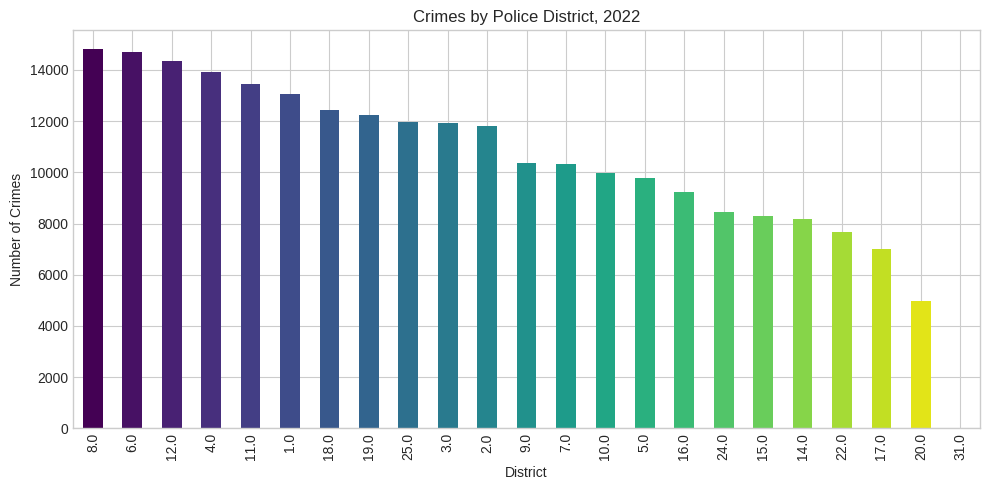

In [19]:
# bar plot to visualizing the total number of crimes per police district in 2022.
crimes_by_district_2022.plot(kind='bar', figsize=(10,5),
                             color=plt.cm.viridis(np.linspace(0, 1, len(crimes_by_district_2022))),
                             title='Crimes by Police District, 2022')
plt.ylabel('Number of Crimes');
plt.xlabel('District');
plt.tight_layout();
plt.show()

**Answer:**

In 2022:

 **District 8 ** had the most reported crimes (14,805), followed closely by District 6 (14,694) and District 12 (14,341).

 **District 31 ** had the fewest, with 15 crimes

##Topic 2: Crimes Across the Years
**Q: Is the total number of crimes increasing or decreasing across the years? Are there any individual crimes doing the opposite?**

In [20]:
#calculating the total number of crimes for each year in the dataset.

#resamble the data by year frequency
total_crime_counts = df.resample('YE').size().rename('total_crime_counts')

#print the first 5 rows
print("Total crime counts per year (first 5 years):")
display(total_crime_counts.head())
#print the last 5 rows
print("\nTotal crime counts per year (last 5 years):")
display(total_crime_counts.tail())

Total crime counts per year (first 5 years):


,total_crime_counts
Date,
2001-12-31,485886
2002-12-31,486807
2003-12-31,475985
2004-12-31,469422
2005-12-31,453773



Total crime counts per year (last 5 years):


,total_crime_counts
Date,
2018-12-31,268899
2019-12-31,261325
2020-12-31,212194
2021-12-31,208824
2022-12-31,238858


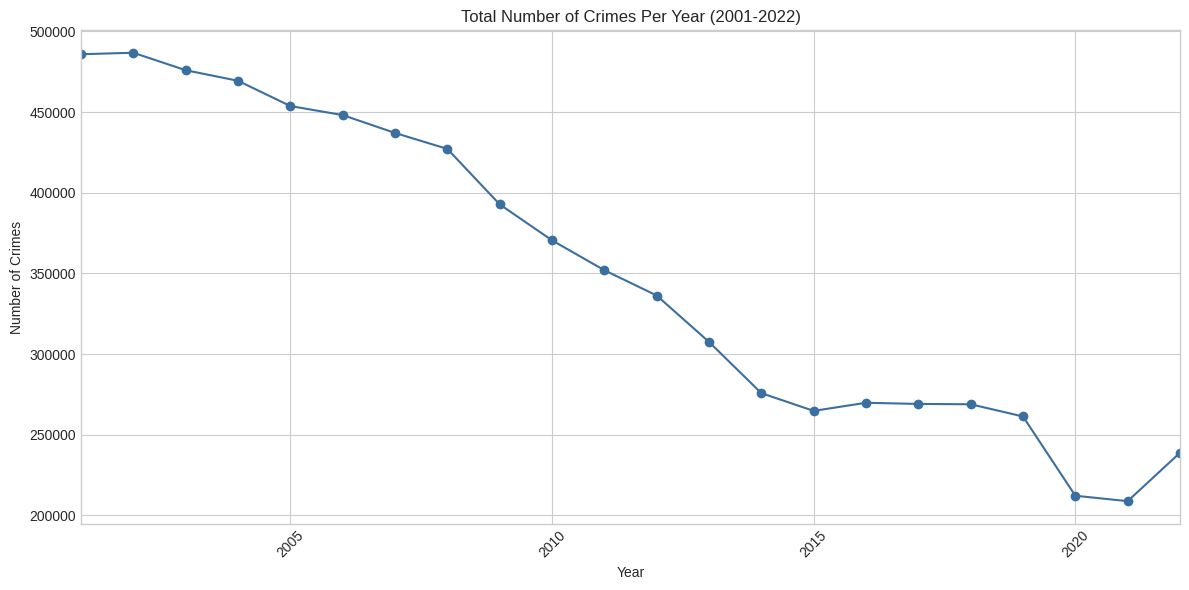

In [21]:
#line plot to show the total number of crimes per year from 2001 to 2022.
plt.figure(figsize=(12, 6))
total_crime_counts.plot(kind='line', marker='o', linestyle='-', color='#3b6fa0')
plt.title('Total Number of Crimes Per Year (2001-2022)')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
#analyzing yearly crime trends by 'Primary Type' using linear regression.

# Group data by year and crime type, count occurrences, then pivot so:
# rows = years (2001-2022), columns = crime types, values = crime count
yearly_by_type = df.groupby([df.index.year, 'Primary Type']).size().unstack(fill_value=0)

# Empty list to store regression results for each crime type
trend_rows = []

# Loop through each crime type (each column in the table)
for col in yearly_by_type.columns:

    # Get the yearly crime counts for this crime type as an array
    y = yearly_by_type[col].values

    # Skip rare crime types with fewer than 500 total crimes across all years
    # (too few data points to produce a reliable trend)
    if y.sum() < 500:
        continue

    # Run linear regression: year (x) vs crime count (y)
    # s = slope (change per year), p = p-value (statistical significance)
    s, i, r, p, se = linregress(yearly_by_type.index, y)

    # Store the crime type name, slope, and p-value
    trend_rows.append((col, s, p))

# Convert results to a DataFrame and sort by slope (highest growth first)
trend_df = pd.DataFrame(trend_rows, columns=['type', 'slope', 'p_value']).sort_values('slope', ascending=False)

# Filter and print only crime types that are:
# 1. Trending UPWARD (positive slope)
# 2. Statistically significant (p-value < 0.05)
print("Crime types INCREASING despite the overall decline (positive slope, p<0.05):")
print(trend_df[(trend_df['slope'] > 0) & (trend_df['p_value'] < 0.05)].to_string(index=False))

Crime types INCREASING despite the overall decline (positive slope, p<0.05):
                             type      slope  p_value
               DECEPTIVE PRACTICE 276.701299 0.000078
                WEAPONS VIOLATION 170.457369 0.001989
          CRIMINAL SEXUAL ASSAULT  54.194805 0.000136
CONCEALED CARRY LICENSE VIOLATION   9.083569 0.000006
                         HOMICIDE   8.574816 0.049157
                        OBSCENITY   2.709204 0.000014


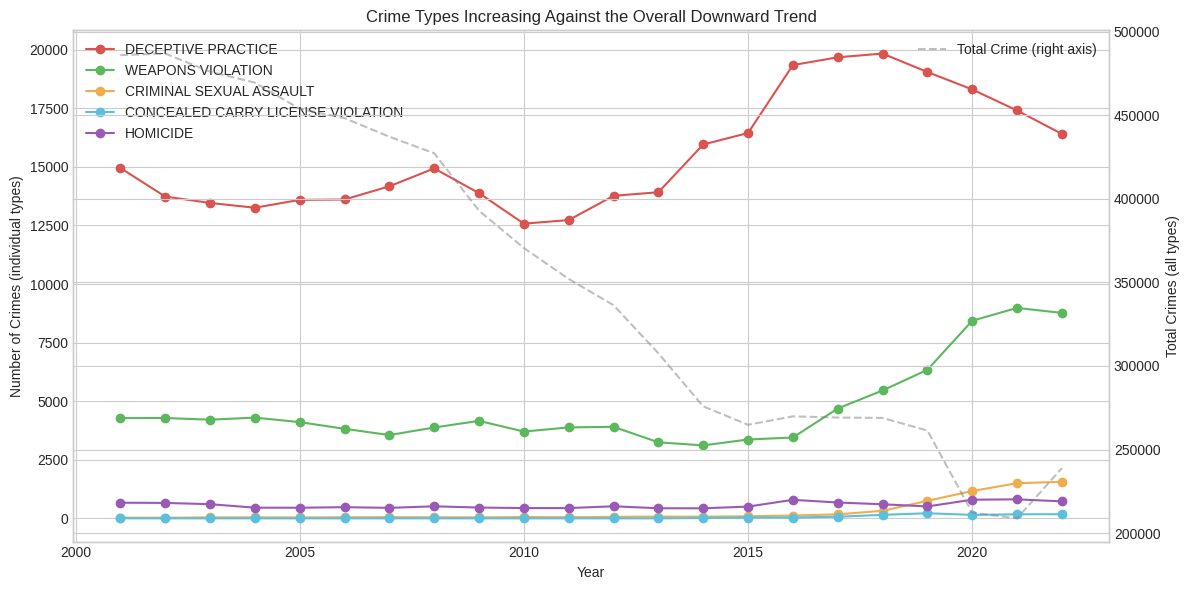

In [23]:
# visualizeing the trends of specific increasing crime types alongside the overall decreasing crime trend.
yearly_total = df.groupby(df.index.year).size()

increasing_crimes = [
    'DECEPTIVE PRACTICE',
    'WEAPONS VIOLATION',
    'CRIMINAL SEXUAL ASSAULT',
    'CONCEALED CARRY LICENSE VIOLATION',
    'HOMICIDE',
    'OBSCENITY'
]

colors = [
    '#d9534f', '#5cb85c', '#f0ad4e', '#5bc0de', '#9b59b6'
]

fig, ax = plt.subplots(figsize=(12, 6))

for c, color in zip(increasing_crimes, colors):
    ax.plot(yearly_by_type.index, yearly_by_type[c], marker='o', label=c, color=color)

ax2 = ax.twinx()
ax2.plot(yearly_total.index, yearly_total.values, color='gray', linestyle='--',
         alpha=0.5, label='Total Crime (right axis)')

ax.set_title('Crime Types Increasing Against the Overall Downward Trend')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Crimes (individual types)')
ax2.set_ylabel('Total Crimes (all types)')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Answer:** Total crime in Chicago has fallen sharply and consistently, from about 486,000 incidents in 2001/2002 down to roughly 209,000–270,000 a year in the 2014–2022 period (a statistically significant decline of about 14,600 fewer crimes/year on average, though the curve flattens after ~2015 and ticks up slightly in 2022).

A handful of categories buck that trend and are trending **up**: **Deceptive Practice** (fraud/financial-identity crimes, +277/year), **Weapons Violations** (+170/year), and **Criminal Sexual Assault** (+54/year). Most other categories — theft, battery, narcotics, burglary — are falling in line with the overall trend.

## Topic 3: Comparing AM vs. PM Rush Hour
**Q: Are crimes more common during AM (7-10AM) or PM (4-7PM) rush hour? What are the top 5 crimes in each window? Is Motor Vehicle Theft more common AM or PM?**

In [24]:
# comparing crime counts during AM (7-10 AM) and PM (4-7 PM) rush hours.

# filtering the DataFrame for these time windows,
hour = df.index.hour
am = df[(hour >= 7) & (hour < 10)]
pm = df[(hour >= 16) & (hour < 19)]

# print the total crimes for each period
print(f"AM rush hour (7-10AM) total crimes: {len(am):,}")
print(f"PM rush hour (4-7PM) total crimes:  {len(pm):,}")

AM rush hour (7-10AM) total crimes: 770,651
PM rush hour (4-7PM) total crimes:  1,206,353


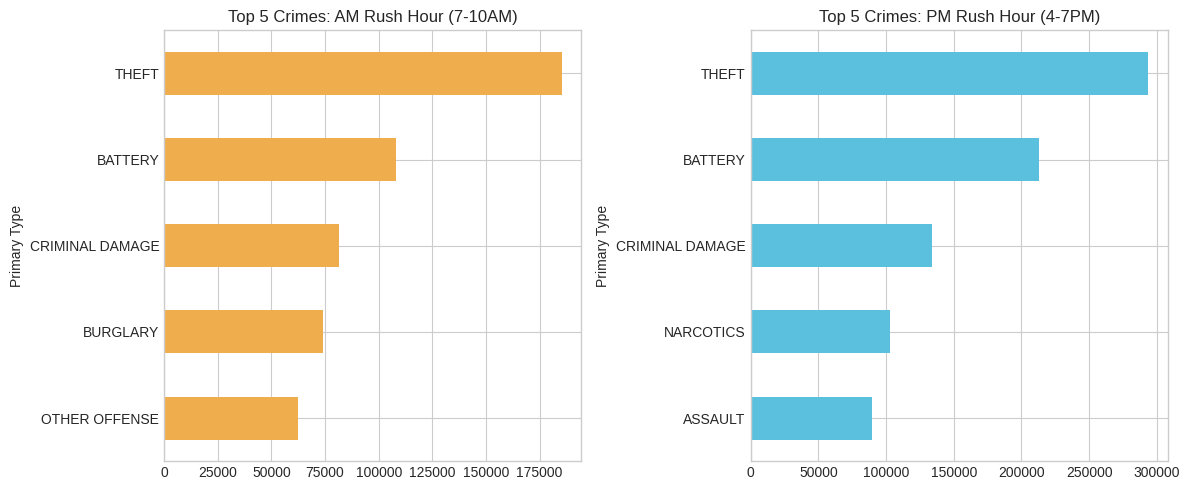

In [25]:
# visualizing the top 5 crime types for both rush hour periods using bar plots.
fig, axes = plt.subplots(1, 2, figsize=(12,5))
am['Primary Type'].value_counts().head(5).plot(kind='barh', ax=axes[0], color='#f0ad4e')
axes[0].set_title('Top 5 Crimes: AM Rush Hour (7-10AM)'); axes[0].invert_yaxis()
pm['Primary Type'].value_counts().head(5).plot(kind='barh', ax=axes[1], color='#5bc0de')
axes[1].set_title('Top 5 Crimes: PM Rush Hour (4-7PM)'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

In [26]:
#comparing the number of 'MOTOR VEHICLE THEFT' incidents during AM and PM rush hours.
mvt_am = (am['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()
mvt_pm = (pm['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()

#print the crime count for each period
print(f"Motor Vehicle Theft — AM: {mvt_am:,} | PM: {mvt_pm:,}")

Motor Vehicle Theft — AM: 41,578 | PM: 53,716


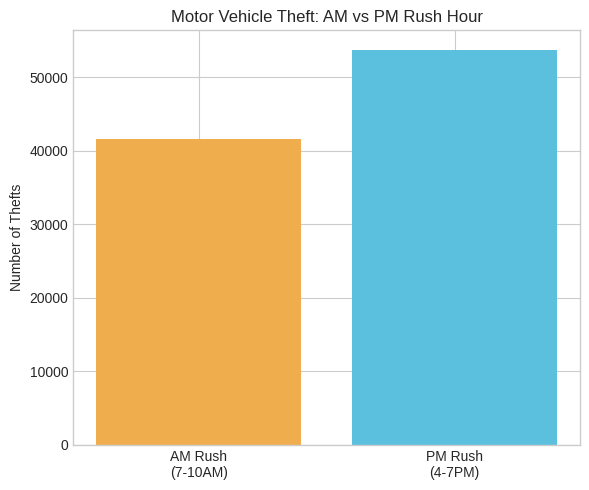

In [27]:
# plot the counts for each period using a bar chart.
plt.figure(figsize=(6,5))
plt.bar(['AM Rush\n(7-10AM)', 'PM Rush\n(4-7PM)'], [mvt_am, mvt_pm], color=['#f0ad4e','#5bc0de'])
plt.title('Motor Vehicle Theft: AM vs PM Rush Hour'); plt.ylabel('Number of Thefts')
plt.tight_layout(); plt.show()

**Answer:** Crime is meaningfully more common during **PM rush hour**: 1,206,353 incidents vs. 770,651 in the AM window (both are equal 3-hour windows, so this is a fair comparison) — PM rush has about 56% more crime.

Top 5 crimes are nearly identical in rank for the top 3 (Theft, Battery, Criminal Damage) in both windows, but **Burglary** is #4 in the AM window (when many homes/businesses are unattended) while **Narcotics** and **Assault** push into the top 5 in the PM window.

**Motor Vehicle Theft is more common in the PM window** (53,716 vs. 41,578), consistent with cars sitting parked and exposed during evening hours.

##Topic 4: Comparing Months
**Q: What months have the most/least crime?**

In [28]:
# calculating the total number of crimes per month across all years combined.
monthly_total = df.groupby(df.index.month).size()
month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

# print the months for the most and least crimes
print("Most crimes (raw total):", calendar.month_name[monthly_total.idxmax()])
print("Least crimes (raw total):", calendar.month_name[monthly_total.idxmin()])

Most crimes (raw total): July
Least crimes (raw total): February


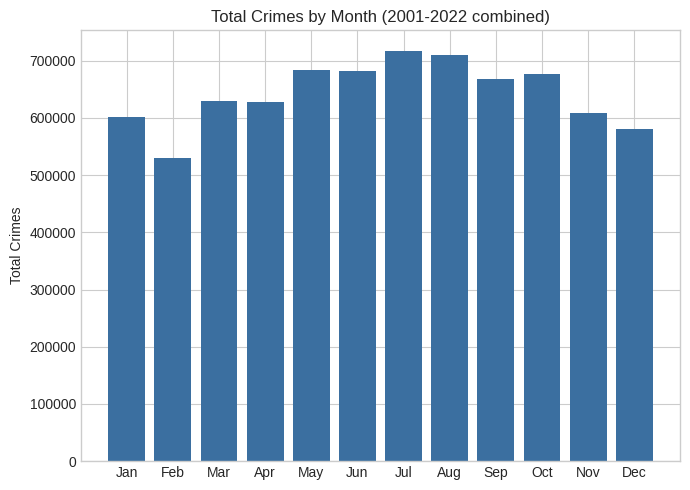

In [29]:
# bar plot to visualize the months with the most and least crimes.
fig, ax = plt.subplots(1, 1, figsize=(7,5))
ax.bar(month_labels, monthly_total.values, color='#3b6fa0')
ax.set_title('Total Crimes by Month (2001-2022 combined)');
ax.set_ylabel('Total Crimes')
plt.tight_layout();
plt.show()

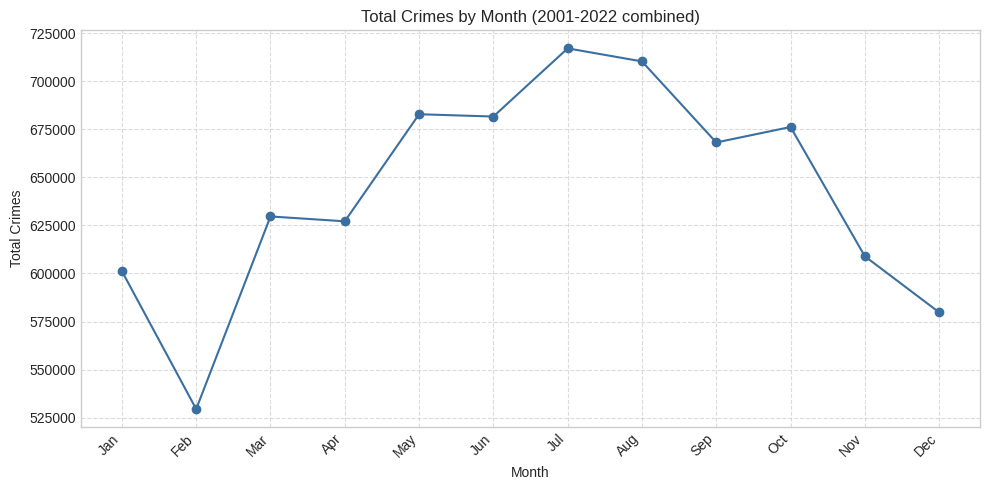

In [30]:
#line plot to visualize the total number of crimes by month, combined across all years.

fig, ax = plt.subplots(figsize=(10, 5))
monthly_total.plot(kind='line', marker='o', color='#3b6fa0', ax=ax)
ax.set_xticks(monthly_total.index)
ax.set_xticklabels(month_labels, rotation=45, ha='right')
ax.set_title('Total Crimes by Month (2001-2022 combined)');
ax.set_xlabel('Month')
ax.set_ylabel('Total Crimes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout();
plt.show()

**Answer:** **July** has the most crime overall, while **February** has the fewest in raw totals — though that's partly just because February is shorter; on a per-day basis, **December** is essentially tied with February for the lowest crime rate. Most crime types follow this same broad "low in winter, peaks in summer" pattern.

## Topic 5: Comparing Holidays
**Q: What are the top 3 holidays with the most crime? For each, what are the top 5 most common crimes?**

In [31]:
# mapping of dates to holiday names for the entire dataset period (2001-2022).

import holidays

#Build a date → holiday name mapping for all years 2001-2022
us_holidays = {}
for year in range(2001, 2023):
    us_holidays.update(holidays.US(state=None, years=year))
#us_holidays is now a dict: {date: "Holiday Name", ...}

#Tag each crime row with its holiday name
df_day = pd.DataFrame({'date': df.index.normalize(), 'Primary Type': df['Primary Type'].values})
df_day['holiday_name'] = df_day['date'].map(us_holidays)

#Count crimes per holiday
by_holiday = df_day.dropna(subset=['holiday_name']).groupby('holiday_name').size().sort_values(ascending=False)

#Drop Juneteenth — only 2 years of data (2021-2022), not comparable
by_holiday_plot = by_holiday.drop("Juneteenth National Independence Day", errors='ignore')

print(by_holiday_plot.head(3))

holiday_name
New Year's Day      32725
Independence Day    22672
Labor Day           22164
dtype: int64


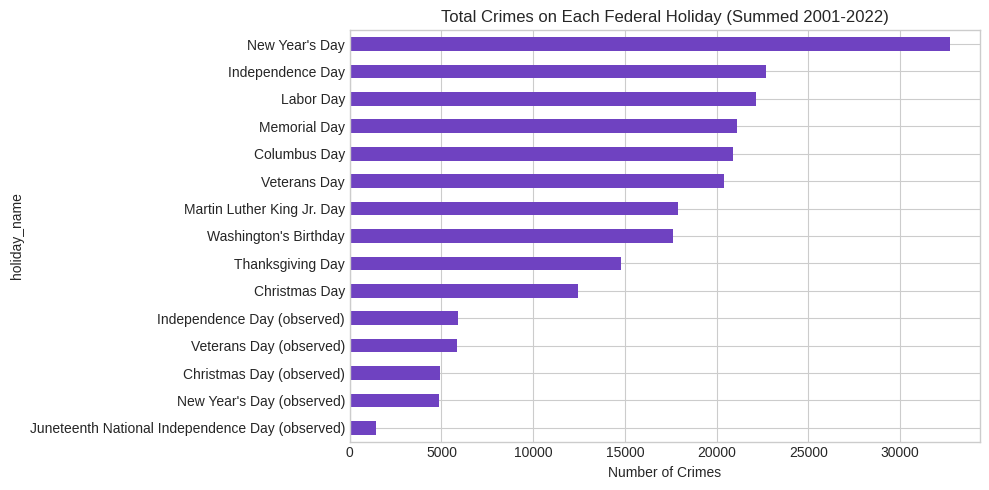

In [32]:
#plots the total number of crimes for each federal holiday, sorted from most to least crimes.

#Plot the holidays from the largest number of crimes to the least
by_holiday_plot.plot(kind='barh', figsize=(10, 5), color='#6f42c1',
                     title='Total Crimes on Each Federal Holiday (Summed 2001-2022)')
plt.xlabel('Number of Crimes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

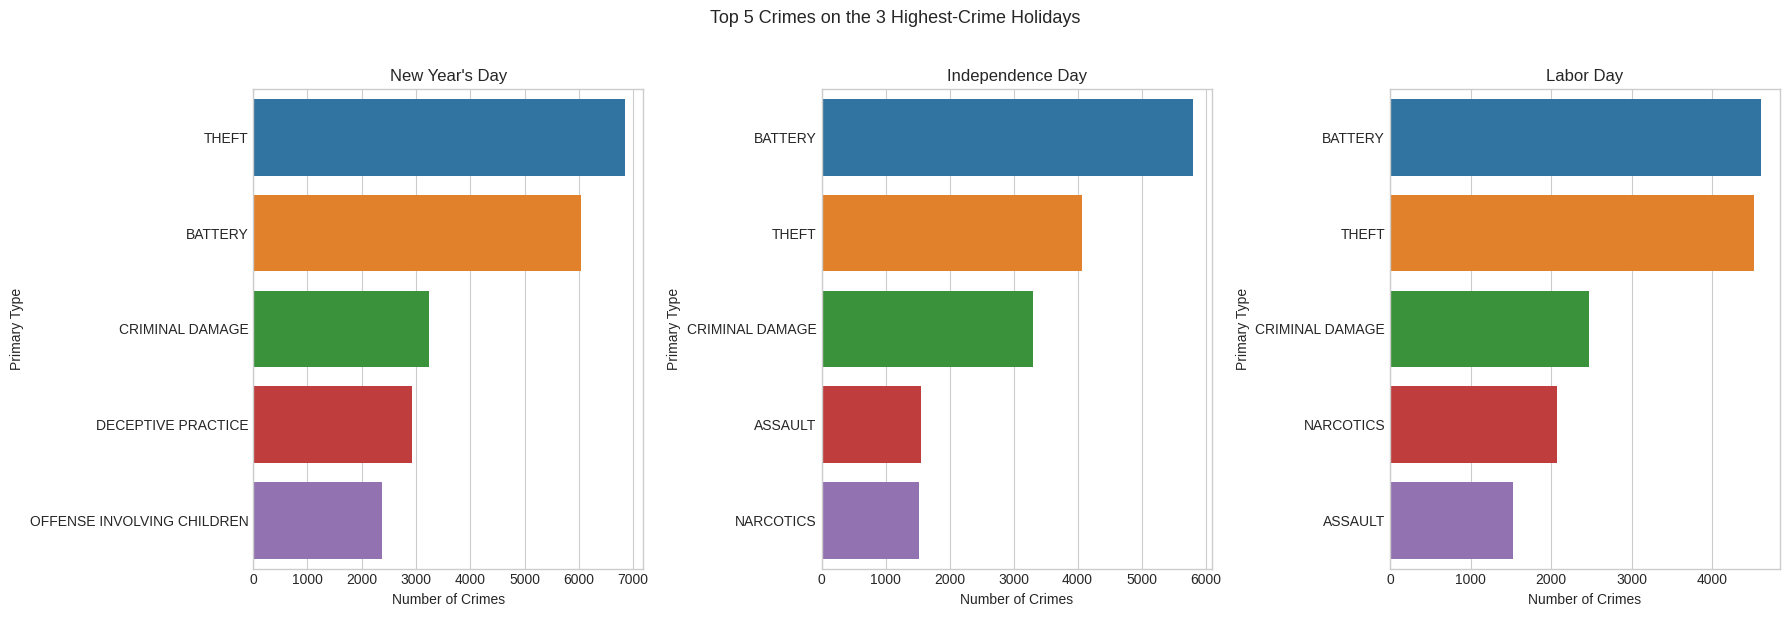

In [33]:
# This cell visualizes the top 5 most common crime types for the top 3 holidays with the highest crime counts.

top3_holidays = by_holiday_plot.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, h in zip(axes, top3_holidays):
    sub = df_day[df_day['holiday_name'] == h]
    top_5_crimes = sub['Primary Type'].value_counts().head(5)
    sns.barplot(x=top_5_crimes.values, y=top_5_crimes.index, palette='tab10', hue=top_5_crimes.index, legend=False, ax=ax)
    ax.set_title(h)
    ax.set_xlabel('Number of Crimes')
    ax.set_ylabel('Primary Type')

plt.suptitle('Top 5 Crimes on the 3 Highest-Crime Holidays', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Answer:** The top 3 holidays for crime (summed across all 22 years) are **New Year's Day** (28,600), **Independence Day** (22,911), and **Labor Day** (22,164) — all "celebration" holidays involving parties, alcohol, and fireworks.

- **New Year's Day:** Theft (5,789), Battery (5,240), Criminal Damage (2,982), Deceptive Practice (2,416), Other Offense (2,096)
- **Independence Day:** Battery (5,717), Theft (4,224), Criminal Damage (3,116), Narcotics (1,703), Assault (1,531)
- **Labor Day:** Battery (4,607), Theft (4,520), Criminal Damage (2,475), Narcotics (2,078), Assault (1,525)

Notably, **Battery** outranks **Theft** on Independence Day and Labor Day but not New Year's Day — consistent with summer holiday gatherings/altercations, versus New Year's overnight opportunistic theft.

##Modeling and forcasting

In [34]:
# Install pmdarima library for auto_arima functionality
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 19.0 MB/s eta 0:00:00


In [35]:
# Import necessary libraries for time series analysis and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import statsmodels.tsa.api as tsa
from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs,nsdiffs

plt.rcParams['figure.figsize']=(12,3)

import warnings
warnings.filterwarnings('ignore')

In [36]:
# Define a helper function to plot time series forecast against actual data
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):

    ### Plot training data, and forecast (with upper/lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                    forecast_df['mean_ci_upper'],
                    color='green', alpha=0.3, lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [37]:
# Define a helper function for the Augmented Dickey-Fuller (ADF) test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()

    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
     icbest ) = tsa.adfuller(ts, **kwargs)

    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        '# of Lags Used':nlags,
                        '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                        'sig/stationary?': pval < alpha}

    return pd.DataFrame(adfuller_results, index =[label])

In [38]:
# Define a helper function to calculate regression metrics for time series models
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error, r2_score, mean_absolute_percentage_error

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True,
                          output_dict=False,):

    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = root_mean_squared_error(ts_true, ts_pred)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "----" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:

        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }

        return metrics

In [39]:
# Define a helper function to identify significant lags in ACF/PACF plots
def get_sig_lags(ts, type='ACF', nlags=None, alpha=0.05):

    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type == 'PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags = range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({'type':corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtract acf to upper ci to center
                           })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags = corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [40]:
# Define a helper function to plot ACF and PACF for time series diagnostics
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=0.05,
                  acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                  seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)

    # Sig lags line style
    sig_vline_kwargs = dict(ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)

    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

###Theft Crime

In [41]:
# Generate monthly time series for 'THEFT' crime counts
ts = df[df['Primary Type'] == 'THEFT'].resample('ME').size().rename('counts')

print("Theft monthly crime counts (first 5 rows):")
display(ts.head())
print("\nTheft monthly crime counts (last 5 rows):")
display(ts.tail())

Theft monthly crime counts (first 5 rows):


,counts
Date,
2001-01-31,7867
2001-02-28,6669
2001-03-31,7766
2001-04-30,7702
2001-05-31,8420



Theft monthly crime counts (last 5 rows):


,counts
Date,
2022-08-31,5244
2022-09-30,5117
2022-10-31,5242
2022-11-30,4717
2022-12-31,4413


In [42]:
# Check for null values in the 'THEFT' monthly time series
theft_null = ts.isna().sum()
print(f"Theft null values: {theft_null}")

Theft null values: 0


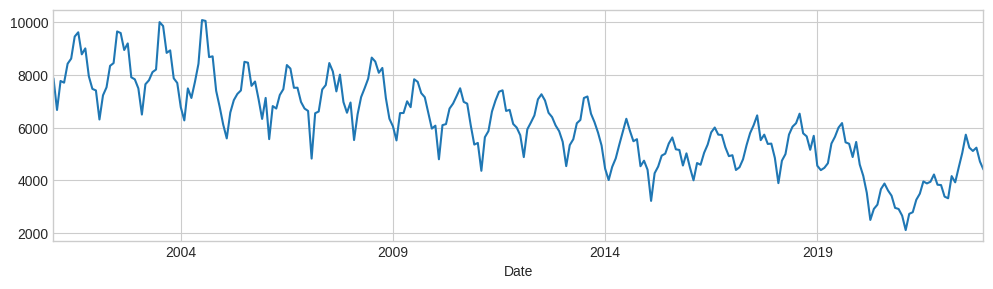

In [43]:
# Plot the 'THEFT' monthly time series
ts.plot();

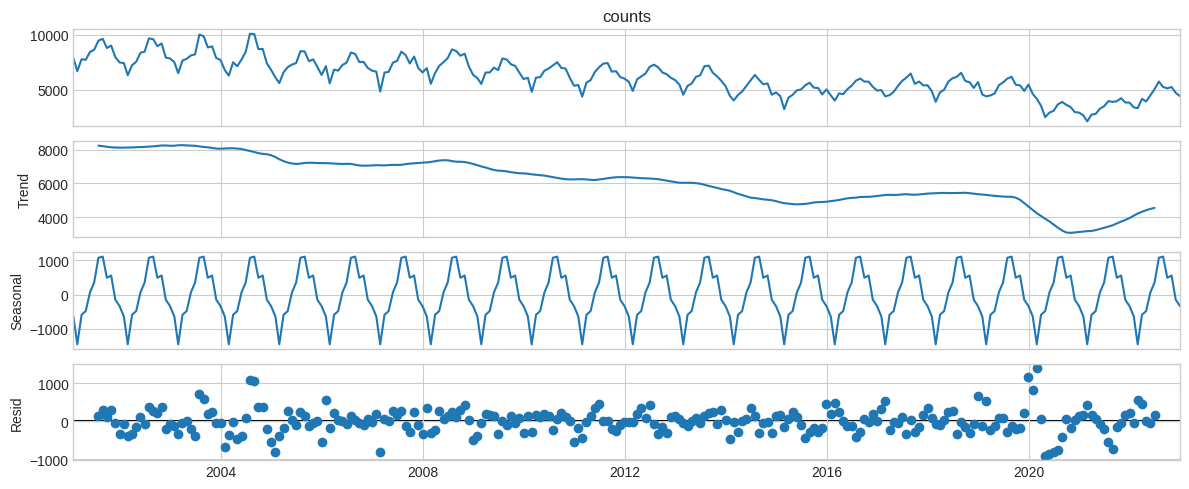

In [44]:
# Perform seasonal decomposition on the 'THEFT' time series
decomp = tsa.seasonal_decompose(ts)
fig = decomp.plot();
fig.set_size_inches(12,5)
fig.tight_layout()

In [45]:
# Calculate the percentage of seasonal variation relative to the overall range for 'THEFT'
sesonal_delta = decomp.seasonal.max() - decomp.seasonal.min()
s = ts.max()-ts.min()
z = sesonal_delta / s*100
print(z)

32.08339324657895


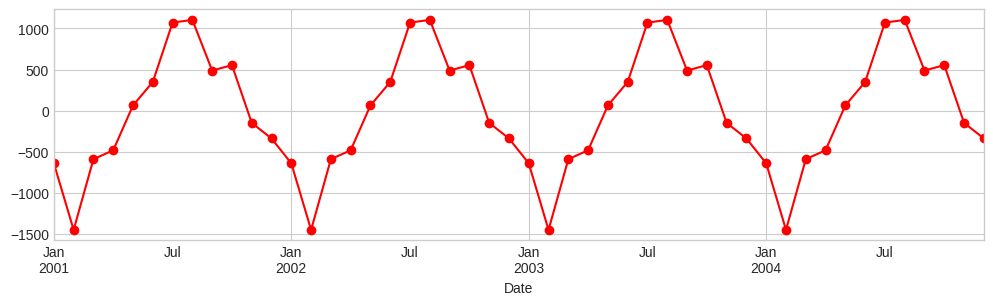

In [46]:
# Plot the seasonal component of the 'THEFT' time series for a few years
seasonal = decomp.seasonal
ax = seasonal.loc['2001':'2004'].plot(marker='o', color='red')

In [47]:
# Perform Augmented Dickey-Fuller test on 'THEFT' time series to check for stationarity
get_adfuller_results(ts)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.393935,13,250,0.58518,0.05,False


In [48]:
# Determine the number of non-seasonal differences (d) needed for 'THEFT' time series
d = ndiffs(ts)
d

1

In [49]:
# Determine the number of seasonal differences (D) needed for 'THEFT' time series
D = nsdiffs(ts, m=12)
D

0

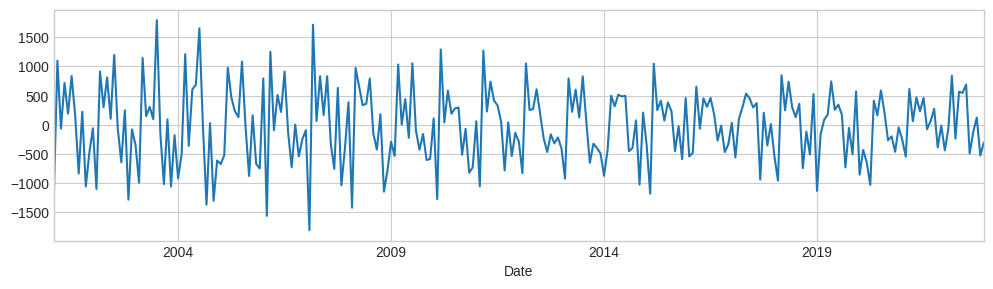

In [50]:
# Apply non-seasonal differencing to the 'THEFT' time series
ts_diff = ts.diff().dropna()
ts_diff.plot();

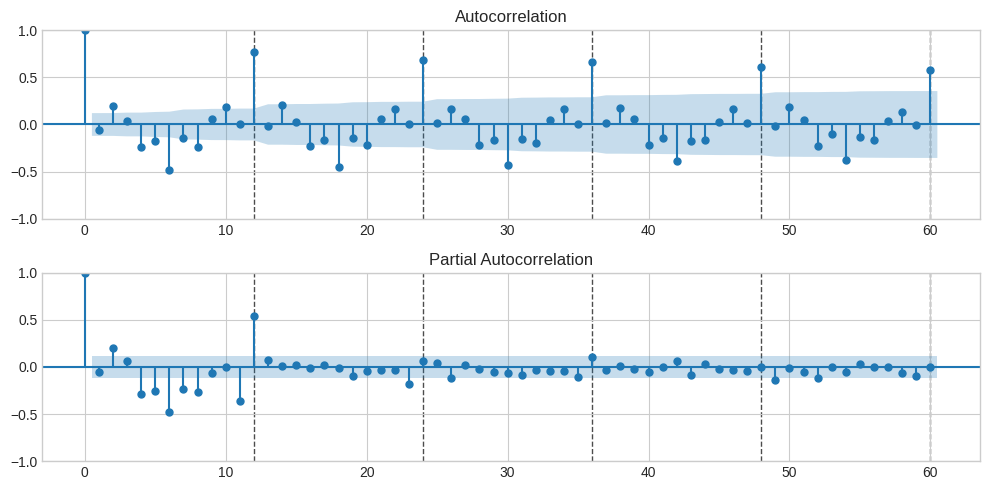

In [51]:
# Plot ACF and PACF of the differenced 'THEFT' time series to identify AR/MA orders
plot_acf_pacf(ts_diff, annotate_seas=True, m=12, nlags=60);

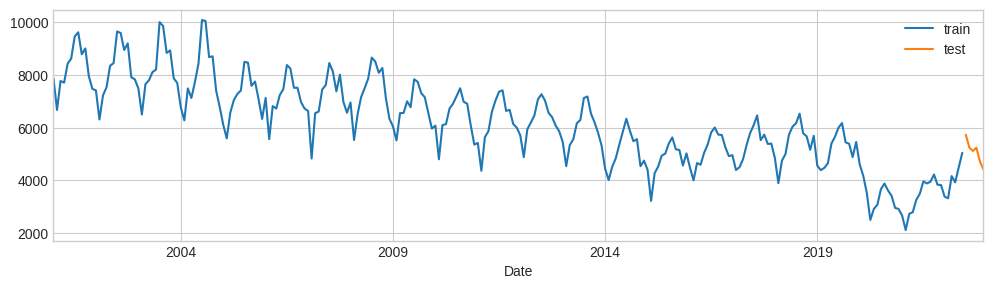

In [52]:
# Split the 'THEFT' time series into training and testing sets
train , test = train_test_split(ts, test_size=6)
ax = train.plot(label='train')
test.plot(ax=ax, label='test')
ax.legend();

In [53]:
# Fit a SARIMA model to the 'THEFT' training data
sarima = tsa.ARIMA(train, order=(1,1,1), seasonal_order=(1,0,0,12)).fit()

--------------------------------------------------------------------------------
Regression Metrics: 
--------------------------------------------------------------------------------
- MAE = 424.993
- MSE = 243,330.332
- RMSE = 493.285
- R^2 = -0.379
- MAPE = 8.77%


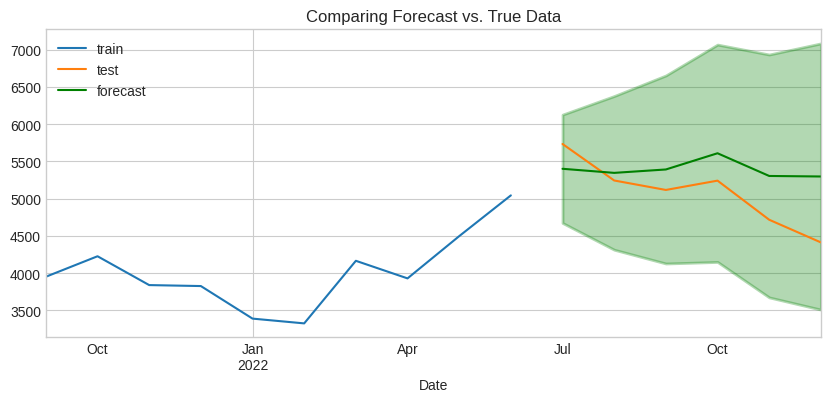

In [54]:
# Generate forecast from the SARIMA model and evaluate its performance for 'THEFT'
forcast_df = sarima.get_forecast(len(test)).summary_frame()
plot_forecast(train, test, forcast_df, n_train_lags=10);
regression_metrics_ts(test, forcast_df['mean'])

In [55]:
# Display the summary of the SARIMA model for 'THEFT'
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                            counts   No. Observations:                  258
Model:             ARIMA(1, 1, 1)x(1, 0, [], 12)   Log Likelihood               -1897.686
Date:                           Fri, 03 Jul 2026   AIC                           3803.371
Time:                                   09:43:43   BIC                           3817.567
Sample:                               01-31-2001   HQIC                          3809.080
                                    - 06-30-2022                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9640      0.171     -5.635      0.000      -1.299      -0.629
ma.L1          0.9701      0.155      6.265      0.000       0.667       1.274
ar.S.L12       0.7794      0.029     26.848      0.000       0.722       0.836
sigma2      1.376e+05   1.04e+04     13.255      0.000    1.17e+05    1.58e+05
===================================================================================
Ljung-Box (L1) (Q):                   9.32   Jarque-Bera (JB):                 4.44
Prob(Q):                              0.00   Prob(JB):                         0.11
Heteroskedasticity (H):               0.72   Skew:                            -0.07
Prob(H) (two-sided):                  0.13   Kurtosis:                         3.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

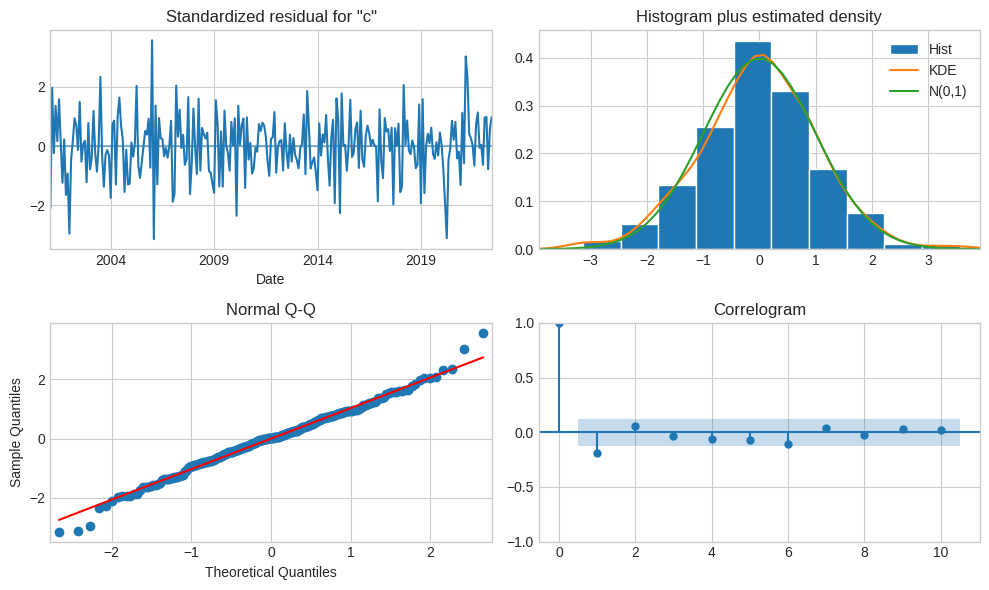

In [56]:
# Plot diagnostic graphs for the SARIMA model for 'THEFT'
fig= sarima.plot_diagnostics();
fig.set_size_inches(10,6)
fig.tight_layout()

In [57]:
# Use pmdarima's auto_arima to automatically find the best ARIMA model for 'THEFT'
import pmdarima as pm

auto_model = pm.auto_arima(train,
                          seasonal=True,
                          m=12,
                          trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=9.63 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4050.524, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3791.710, Time=1.36 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3914.631, Time=0.93 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4048.603, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4050.805, Time=0.10 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=3774.214, Time=6.37 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3743.851, Time=5.30 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3743.960, Time=1.32 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.48 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3742.901, Time=6.72 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3870.719, Time=1.63 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3913.736, Time=0.39 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=3754.859, Time=2.43 sec
 ARIMA(2,1,0)(1,0,2)[12] inte

--------------------------------------------------------------------------------
Regression Metrics: 
--------------------------------------------------------------------------------
- MAE = 211.158
- MSE = 72,805.087
- RMSE = 269.824
- R^2 = 0.587
- MAPE = 4.27%


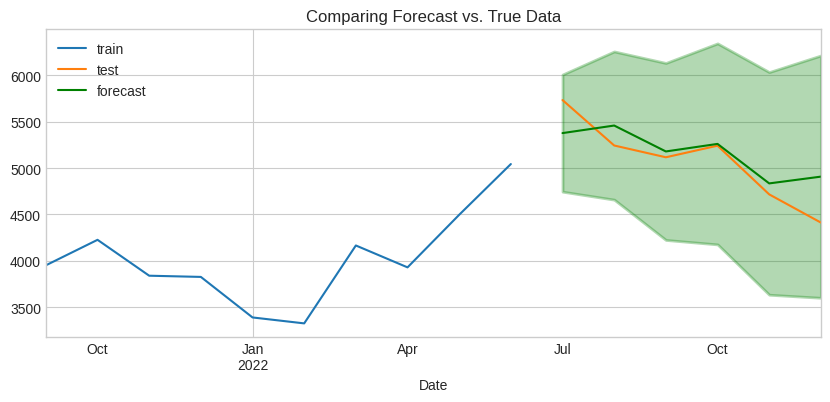

In [58]:
# Fit the best auto_arima model and evaluate its forecast performance for 'THEFT'
best_model = tsa.ARIMA(train, order=auto_model.order, seasonal_order=auto_model.seasonal_order).fit()
forcast_df = best_model.get_forecast(len(test)).summary_frame()
plot_forecast(train, test, forcast_df,n_train_lags=10);
regression_metrics_ts(test, forcast_df['mean'])

In [59]:
# Display the summary of the auto_arima model for 'THEFT'
best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                       
=============================================================================================
Dep. Variable:                                counts   No. Observations:                  258
Model:             ARIMA(1, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood               -1865.634
Date:                               Fri, 03 Jul 2026   AIC                           3741.268
Time:                                       09:45:20   BIC                           3759.013
Sample:                                   01-31-2001   HQIC                          3748.404
                                        - 06-30-2022                                         
Covariance Type:                                 opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2251      0.046     -4.934      0.000      -0.315      -0.136
ar.S.L12       0.9778      0.008    120.055      0.000       0.962       0.994
ma.S.L12      -0.5771      0.059     -9.815      0.000      -0.692      -0.462
ma.S.L24      -0.1202      0.068     -1.758      0.079      -0.254       0.014
sigma2      1.038e+05   7353.336     14.120      0.000    8.94e+04    1.18e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                30.54
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               0.80   Skew:                            -0.44
Prob(H) (two-sided):                  0.31   Kurtosis:                         4.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

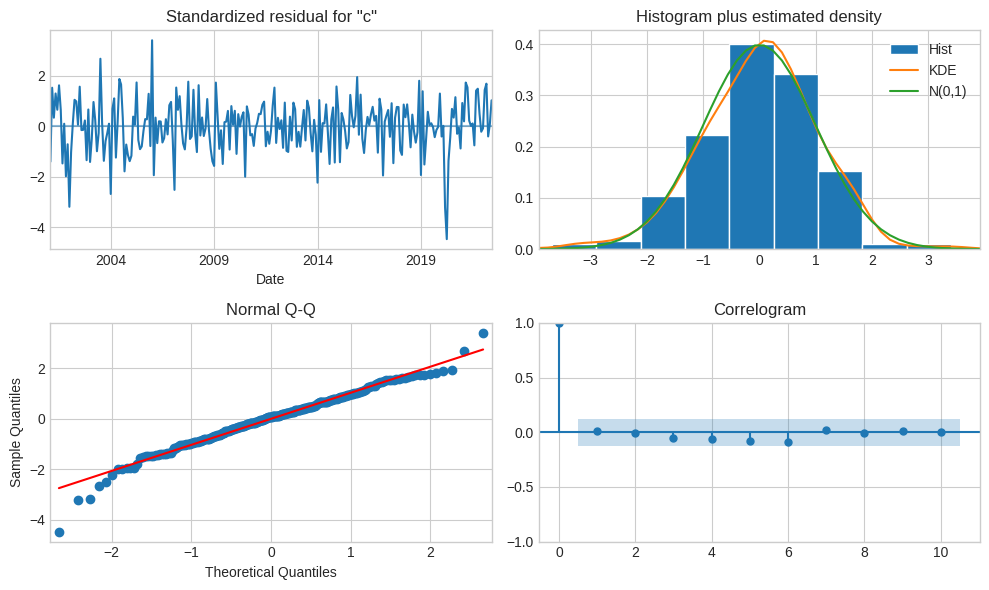

In [60]:
# Plot diagnostic graphs for the auto_arima model for 'THEFT'
fig= best_model.plot_diagnostics();
fig.set_size_inches(10,6)
fig.tight_layout()

 **Final Model Choice**

The `auto_arima` model (ARIMA(1,1,0)(1,0,2,12)) is chosen as the final model due to its superior performance across multiple evaluation metrics and information criteria:

- **Lower Error Metrics**: The `auto_arima` model achieved significantly lower Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) on the test set compared to the SARIMA model. This indicates better accuracy in forecasting.

    - **`auto_arima`**: MAE = 211.158, MSE = 72,805.087, RMSE = 269.824, MAPE = 4.27%
    - **SARIMA**: MAE = 424.993, MSE = 243,330.332, RMSE = 493.285, MAPE = 8.77%

- **Higher R-squared**: The `auto_arima` model yielded a much higher R-squared value (0.587) compared to the SARIMA model (-0.379), suggesting that it explains a greater proportion of the variance in the target variable.

- **Lower AIC and BIC**: The `auto_arima` model also has lower Akaike Information Criterion (AIC = 3741.268) and Bayesian Information Criterion (BIC = 3759.013) values compared to the SARIMA model (AIC = 3803.371, BIC = 3817.567). Lower AIC and BIC generally indicate a better model fit while penalizing for model complexity, confirming the `auto_arima` model as the preferred choice.

In [61]:
# Fit the final chosen model (auto_arima) to the entire 'THEFT' time series
final_model = tsa.ARIMA(ts, order=(1,1,0),
                        seasonal_order=(1,0,2,12)).fit()

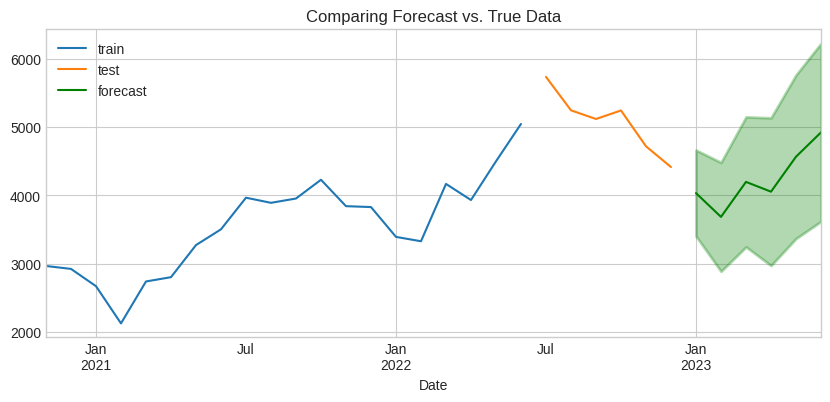

In [62]:
# Generate future forecast using the final model for 'THEFT'
future_forecast_df = final_model.get_forecast(len(test)).summary_frame()
plot_forecast(train, test, future_forecast_df,n_train_lags=20);

In [63]:
# Define the starting value of the 'THEFT' forecast
start_value = future_forecast_df['mean'].iloc[0]
start_value

np.float64(4031.3765811693797)

In [64]:
# Define the final value of the 'THEFT' forecast
final_value = future_forecast_df['mean'].iloc[-1]
final_value

np.float64(4920.785119087922)

In [65]:
# Calculate the net change in 'THEFT' forecast
change = final_value - start_value
change

np.float64(889.4085379185422)

In [66]:
# Calculate the percentage change in 'THEFT' forecast
perc_change = (final_value - start_value) / start_value * 100
perc_change

np.float64(22.06215470102651)

###Battery Crime

In [67]:
# Generate monthly time series for 'BATTERY' crime counts
ts = df[df['Primary Type'] == 'BATTERY'].resample('ME').size().rename('counts')

print("Theft monthly crime counts (first 5 rows):")
display(ts.head())
print("\nTheft monthly crime counts (last 5 rows):")
display(ts.tail())

Theft monthly crime counts (first 5 rows):


,counts
Date,
2001-01-31,6527
2001-02-28,6042
2001-03-31,7662
2001-04-30,8328
2001-05-31,8887



Theft monthly crime counts (last 5 rows):


,counts
Date,
2022-08-31,3740
2022-09-30,3723
2022-10-31,3501
2022-11-30,3083
2022-12-31,3009


In [68]:
# Check for null values in the 'BATTERY' monthly time series
battery_null = ts.isna().sum()
print(f"Theft null values: {battery_null}")

Theft null values: 0


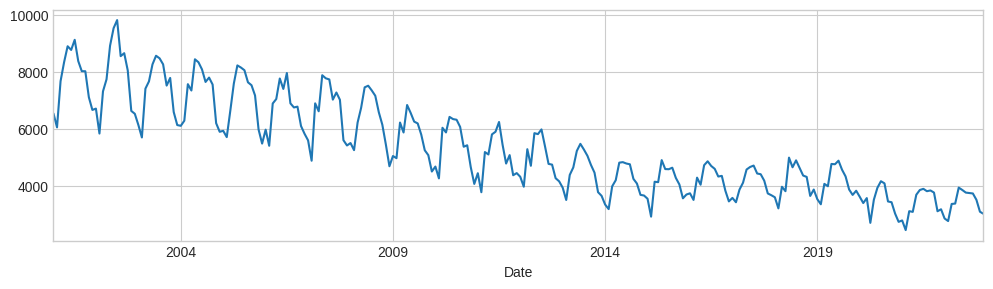

In [69]:
# Plot the 'BATTERY' monthly time series
ts.plot();

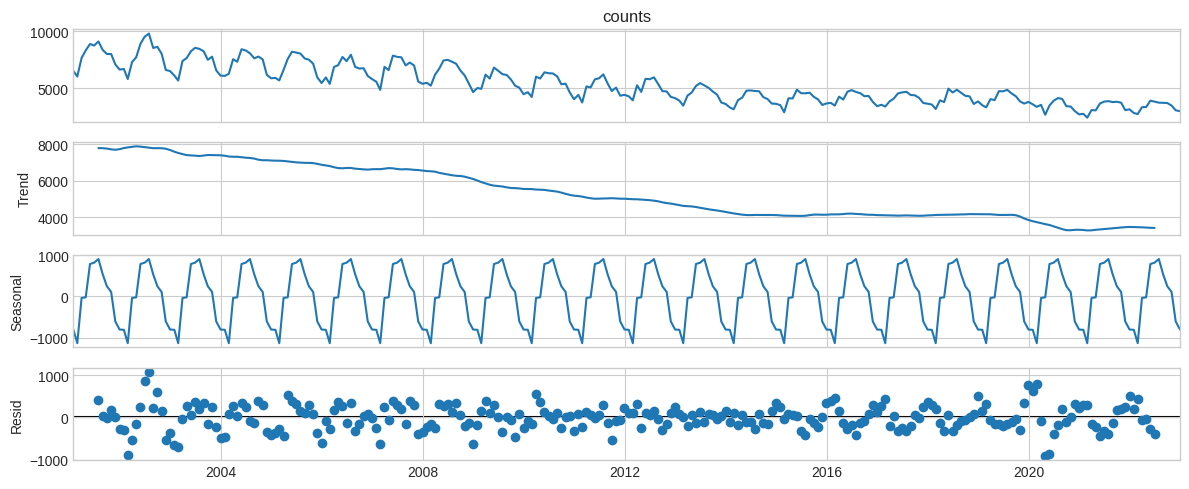

In [70]:
# Perform seasonal decomposition on the 'BATTERY' time series
decomp = tsa.seasonal_decompose(ts)
fig = decomp.plot();
fig.set_size_inches(12,5)
fig.tight_layout()

In [71]:
# Calculate the percentage of seasonal variation relative to the overall range for 'BATTERY'
sesonal_delta = decomp.seasonal.max() - decomp.seasonal.min()
s = ts.max()-ts.min()
z = sesonal_delta / s*100
print(z)

27.69656486904654


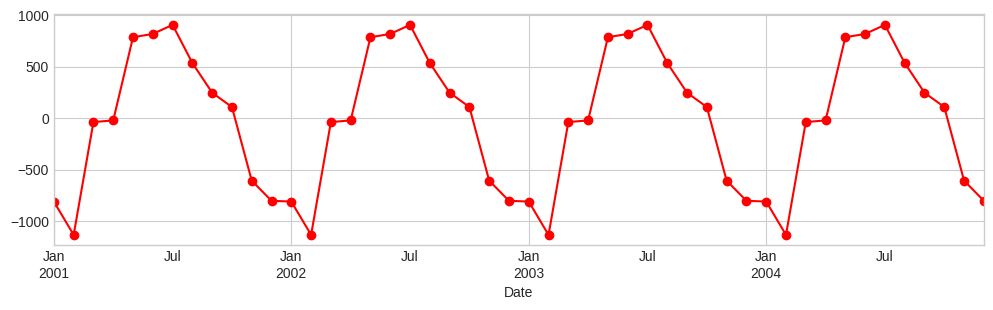

In [72]:
# Plot the seasonal component of the 'BATTERY' time series for a few years
seasonal = decomp.seasonal
ax = seasonal.loc['2001':'2004'].plot(marker='o', color='red')

In [73]:
# Perform Augmented Dickey-Fuller test on 'BATTERY' time series to check for stationarity
get_adfuller_results(ts)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.036843,15,248,0.739591,0.05,False


In [74]:
# Determine the number of non-seasonal differences (d) needed for 'BATTERY' time series
d = ndiffs(ts)
d

1

In [75]:
# Determine the number of seasonal differences (D) needed for 'BATTERY' time series
D = nsdiffs(ts, m=12)
D

0

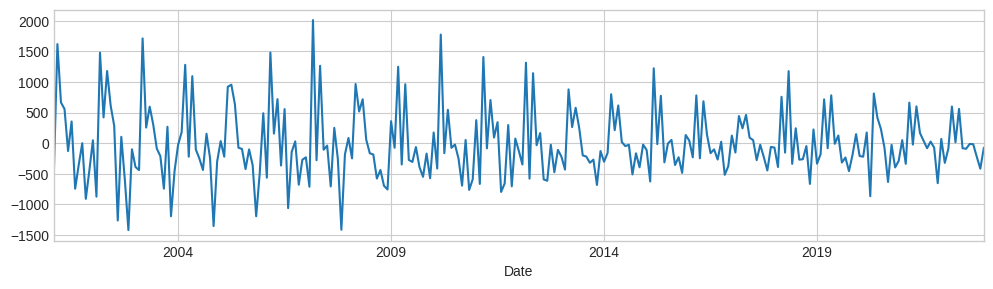

In [76]:
# Apply non-seasonal differencing to the 'BATTERY' time series
ts_diff = ts.diff().dropna()
ts_diff.plot();

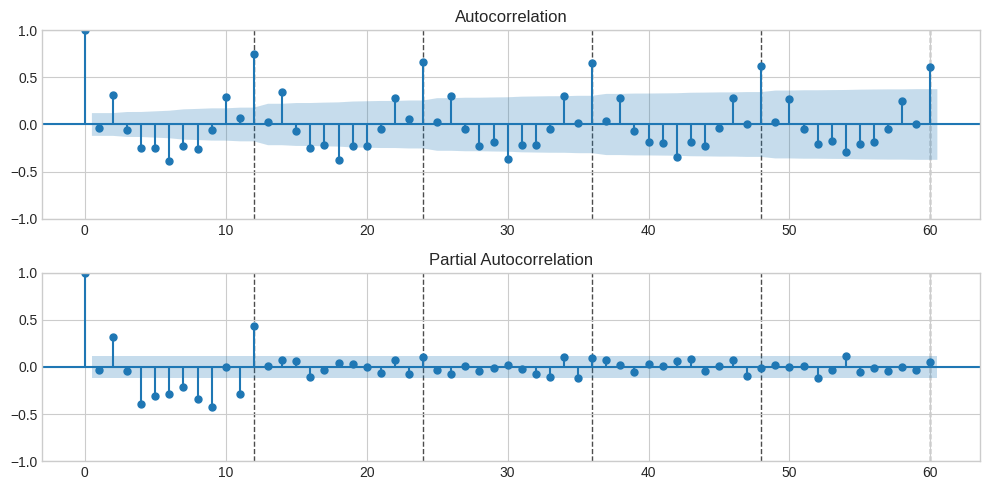

In [77]:
# Plot ACF and PACF of the differenced 'BATTERY' time series to identify AR/MA orders
plot_acf_pacf(ts_diff, annotate_seas=True, m=12, nlags=60);

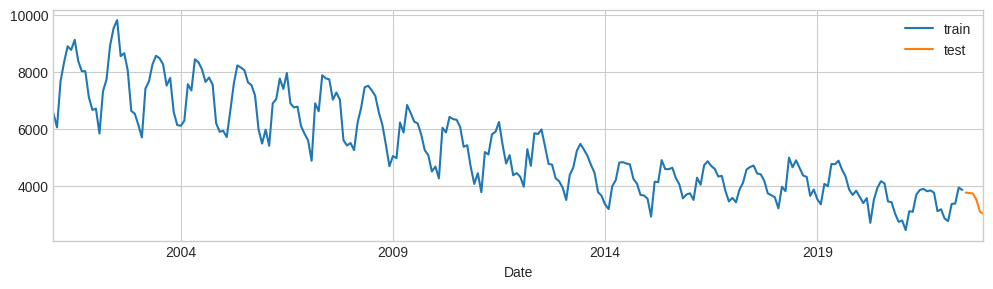

In [78]:
# Split the 'BATTERY' time series into training and testing sets
train , test = train_test_split(ts, test_size=6)
ax = train.plot(label='train')
test.plot(ax=ax, label='test')
ax.legend();

In [79]:
# Fit a SARIMA model to the 'BATTERY' training data
sarima = tsa.ARIMA(train, order=(1,1,0),
                   seasonal_order=(1,0,1,12)).fit()

--------------------------------------------------------------------------------
Regression Metrics: 
--------------------------------------------------------------------------------
- MAE = 107.201
- MSE = 16,068.721
- RMSE = 126.762
- R^2 = 0.834
- MAPE = 3.02%


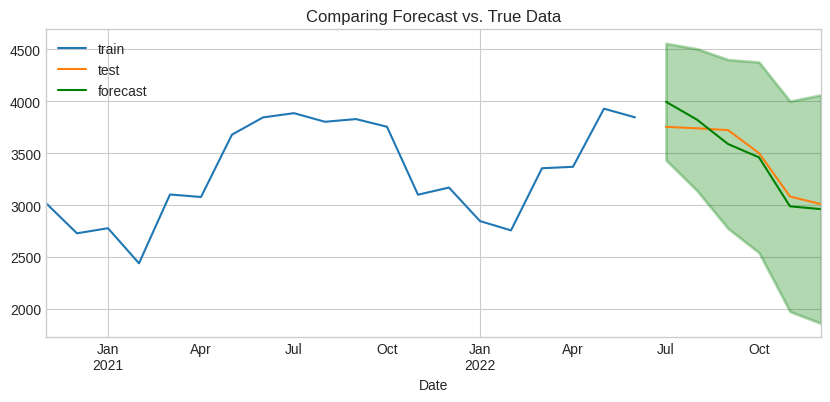

In [80]:
# Generate forecast from the SARIMA model and evaluate its performance for 'BATTERY'
forcast_df = sarima.get_forecast(len(test)).summary_frame()
plot_forecast(train, test, forcast_df, n_train_lags=20);
regression_metrics_ts(test, forcast_df['mean'])

In [81]:
# Display the summary of the SARIMA model for 'BATTERY'
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                             counts   No. Observations:                  258
Model:             ARIMA(1, 1, 0)x(1, 0, [1], 12)   Log Likelihood               -1835.526
Date:                            Fri, 03 Jul 2026   AIC                           3679.053
Time:                                    09:45:33   BIC                           3693.249
Sample:                                01-31-2001   HQIC                          3684.762
                                     - 06-30-2022                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3110      0.053     -5.905      0.000      -0.414      -0.208
ar.S.L12       0.9833      0.006    159.452      0.000       0.971       0.995
ma.S.L12      -0.7005      0.055    -12.715      0.000      -0.808      -0.593
sigma2      8.246e+04   7174.878     11.493      0.000    6.84e+04    9.65e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 1.35
Prob(Q):                              0.70   Prob(JB):                         0.51
Heteroskedasticity (H):               0.41   Skew:                            -0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

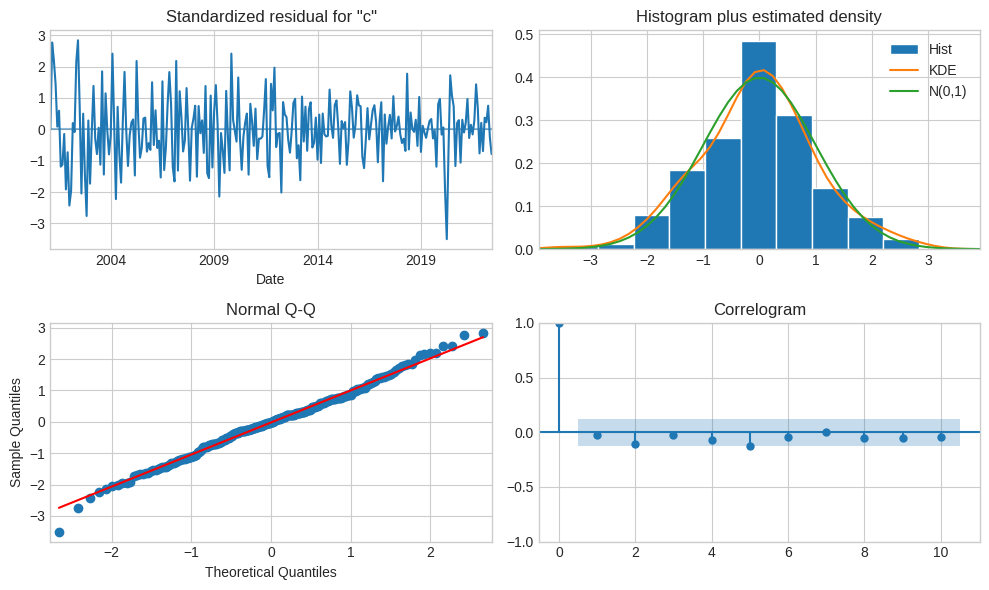

In [82]:
# Plot diagnostic graphs for the SARIMA model for 'BATTERY'
fig= sarima.plot_diagnostics();
fig.set_size_inches(10,6)
fig.tight_layout()

In [83]:
# Use pmdarima's auto_arima to automatically find the best ARIMA model for 'BATTERY'
import pmdarima as pm

auto_model = pm.auto_arima(train,
                          seasonal=True,
                          m=12,
                          trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=3.98 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3999.181, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3753.329, Time=2.18 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3872.017, Time=1.14 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3997.267, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4000.706, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=2.11 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3680.737, Time=2.25 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3870.170, Time=0.45 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3688.922, Time=3.34 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3682.671, Time=3.79 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3836.662, Time=2.85 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=5.18 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=3704.855, Time=1.10 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept

--------------------------------------------------------------------------------
Regression Metrics: 
--------------------------------------------------------------------------------
- MAE = 95.192
- MSE = 17,440.190
- RMSE = 132.061
- R^2 = 0.820
- MAPE = 2.61%


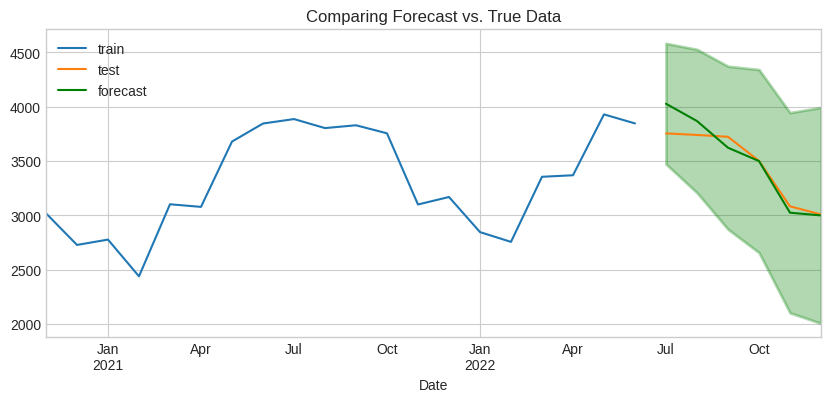

In [84]:
# Fit the best auto_arima model and evaluate its forecast performance for 'BATTERY'
best_model = tsa.ARIMA(train, order=auto_model.order, seasonal_order=auto_model.seasonal_order).fit()
forcast_df = best_model.get_forecast(len(test)).summary_frame()
plot_forecast(train, test, forcast_df,n_train_lags=20);
regression_metrics_ts(test, forcast_df['mean'])

In [85]:
# Display the summary of the auto_arima model for 'BATTERY'
best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                             counts   No. Observations:                  258
Model:             ARIMA(2, 1, 0)x(1, 0, [1], 12)   Log Likelihood               -1833.518
Date:                            Fri, 03 Jul 2026   AIC                           3677.037
Time:                                    09:47:08   BIC                           3694.782
Sample:                                01-31-2001   HQIC                          3684.173
                                     - 06-30-2022                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3590      0.056     -6.388      0.000      -0.469      -0.249
ar.L2         -0.1261      0.055     -2.290      0.022      -0.234      -0.018
ar.S.L12       0.9840      0.006    169.145      0.000       0.973       0.995
ma.S.L12      -0.6853      0.057    -12.115      0.000      -0.796      -0.574
sigma2      8.026e+04   6989.335     11.484      0.000    6.66e+04     9.4e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.84
Prob(Q):                              0.94   Prob(JB):                         0.40
Heteroskedasticity (H):               0.42   Skew:                             0.01
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

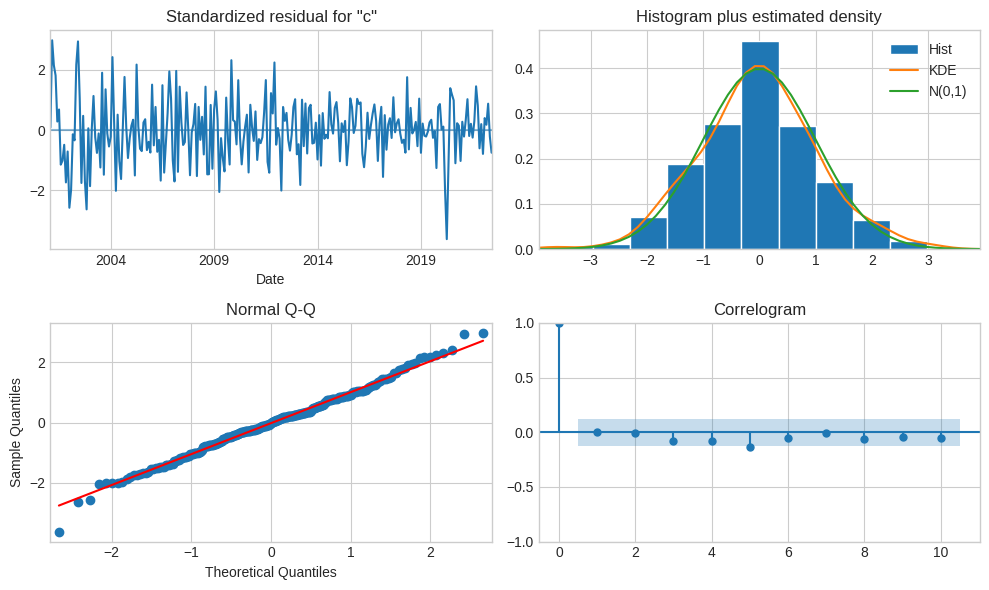

In [86]:
# Plot diagnostic graphs for the auto_arima model for 'BATTERY'
fig= best_model.plot_diagnostics();
fig.set_size_inches(10,6)
fig.tight_layout()

 **Final Model Choice**

For Battery crimes, the `auto_arima` model (ARIMA(2,1,0)(1,0,1)[12]) is chosen as the final model.

**Justification:**

- **Lower Error Metrics**: The `auto_arima` model achieved lower Mean Absolute Error (MAE = 95.192) and Mean Absolute Percentage Error (MAPE = 2.61%) on the test set compared to the SARIMA model (MAE = 107.201, MAPE = 3.02%). These metrics are crucial for assessing the practical accuracy of forecasts.

- **Lower AIC**: The `auto_arima` model has a slightly lower Akaike Information Criterion (AIC = 3677.037) compared to the SARIMA model (AIC = 3679.053), indicating a marginally better fit while accounting for model complexity.

In [87]:
# Fit the final chosen model (auto_arima) to the entire 'BATTERY' time series
final_model = tsa.ARIMA(ts, order=(2,1,0),
                        seasonal_order=(1,0,1,12)).fit()

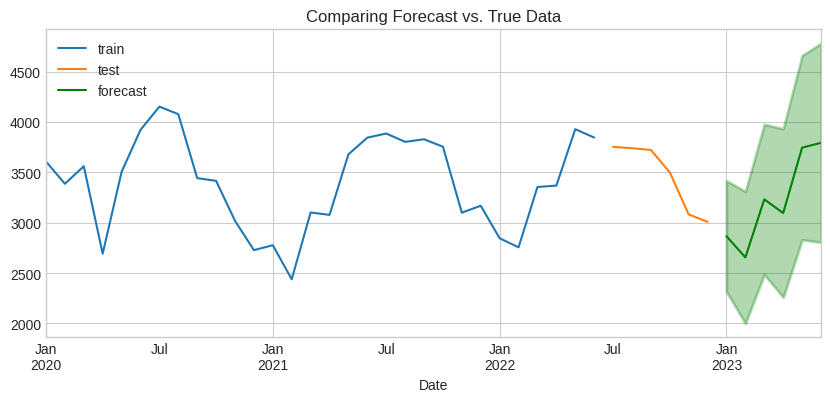

In [88]:
# Generate future forecast using the final model for 'BATTERY'
future_forecast_df = final_model.get_forecast(len(test)).summary_frame()
plot_forecast(train, test, future_forecast_df,n_train_lags=30);

In [89]:
# Define the starting value of the 'BATTERY' forecast
start_value = future_forecast_df['mean'].iloc[0]
start_value

np.float64(2866.5919284893184)

In [90]:
# Define the final value of the 'BATTERY' forecast
final_value = future_forecast_df['mean'].iloc[-1]
final_value

np.float64(3793.4853294480654)

In [91]:
# Calculate the net change in 'BATTERY' forecast
change = final_value - start_value
change

np.float64(926.893400958747)

In [92]:
# Calculate the percentage change in 'BATTERY' forecast
perc_change = (final_value - start_value) / start_value * 100
perc_change

np.float64(32.334333734317596)

###Final Evaluation

**Q1: Which of the two Crimes forecasted to have the highest monthly count of crimes at the end of the forecast?**

*   **THEFT**: The forecasted monthly count at the end of the forecast is approximately **4920.79**.
*   **BATTERY**: The forecasted monthly count at the end of the forecast is approximately **3793.49**.

**Answer: THEFT** is forecasted to have the highest monthly count of crimes at the end of the forecast.

**Q2: Which of the two Crimes forecasted to have the highest net change at the end of the forecast?**

*   **THEFT**: The net change in forecasted crimes is approximately **889.41**.
*   **BATTERY**: The net change in forecasted crimes is approximately **926.89**.

**Answer: BATTERY** is forecasted to have the highest net change at the end of the forecast.

**Q3: Which of the two Crimes forecasted to have the highest percent change at the end of the forecast?**

*   **THEFT**: The percentage change in forecasted crimes is approximately **22.06%**.
*   **BATTERY**: The percentage change in forecasted crimes is approximately **32.33%**.

**Answer: BATTERY** is forecasted to have the highest percentage change at the end of the forecast.

###Final Recommendations for Stakeholders

Based on the analysis of Chicago crime data from 2001-2022, here are key recommendations for stakeholders:

#### 1. Acknowledge Overall Success but Focus Resources Strategically

**Recommendation:** While total crime has significantly decreased over the past two decades (as seen in the **Overall Crime Trend (2001-2022)** visual), stakeholders should not become complacent. Instead, resources should be re-allocated from generally declining crime areas to those showing persistent increases or specific vulnerabilities.

**Justification:** The overall trend is positive, but a deeper dive reveals critical areas that require urgent attention to ensure public safety continues to improve.

#### 2. Implement Targeted Interventions for Increasing Crime Types

**Recommendation:** Develop and deploy specific programs and law enforcement strategies for crimes that are trending upwards (as highlighted in the **Crime Types Increasing Against Overall Downward Trend** visual).

*   **Deceptive Practice:** Launch public awareness campaigns on fraud prevention, invest in cybercrime units, and collaborate with financial institutions to combat identity theft and online scams.
*   **Weapons Violations & Homicide:** Enhance community-based violence reduction programs, strengthen gun control enforcement, and increase police presence in high-risk areas identified through predictive policing models. The increasing trend of homicide, though slight, is concerning and demands dedicated efforts.
*   **Criminal Sexual Assault:** Improve victim support services, enhance prevention education, and increase resources for investigating and prosecuting these sensitive cases.
*   **Concealed Carry License Violations:** Review and strengthen regulations around concealed carry permits and increase monitoring to prevent illegal use.

**Justification:** These crime types actively defy the overall downward trend, indicating a need for specialized and sustained efforts to reverse their growth.

#### 3. Optimize Patrols for Peak Crime Times and Locations

**Recommendation:** Increase law enforcement visibility and patrol density during PM rush hour and in specific areas prone to Motor Vehicle Theft.

*   **PM Rush Hour Focus:** Prioritize police deployment during **PM rush hour (4-7 PM)**, which consistently shows significantly higher crime rates than AM rush hour (as demonstrated in the **AM vs PM Rush Hour Crime Comparison (Motor Vehicle Theft)** visual).
*   **Motor Vehicle Theft Prevention:** Implement targeted patrols in areas with high motor vehicle theft during PM hours, and promote public awareness campaigns encouraging citizens to secure vehicles and use anti-theft devices, especially during evenings.

**Justification:** Data clearly indicates higher crime volumes during PM rush hour, and Motor Vehicle Theft specifically spikes during these times (as seen in the **AM vs PM Rush Hour Crime Comparison (Motor Vehicle Theft)** visual), making targeted resource allocation efficient.

#### 4. Seasonal Deployment Adjustments

**Recommendation:** Adjust law enforcement staffing and community outreach efforts according to seasonal crime patterns, with increased vigilance during summer months and specific holidays.

*   **Summer Surge:** Allocate more resources to public spaces and recreational areas during **July and other summer months** (as shown in the **Total Crimes by Month (2001-2022 combined)** visual), as crime tends to peak during these periods. This may include increased foot patrols, community engagement events, and youth programs to deter criminal activity.
*   **Holiday Planning:** Implement enhanced security measures and public awareness campaigns around **New Year's Day, Independence Day, and Labor Day** (as identified in the **Top 5 Crimes on the 3 Highest-Crime Holidays** visual). Focus interventions on reducing battery and theft incidents during these celebration-heavy holidays, potentially through increased monitoring of large gatherings and enforcing public order.

**Justification:** Crime rates show clear seasonal variations, with a peak in summer and specific holidays being high-risk periods, allowing for proactive crime prevention strategies.